<a href="https://colab.research.google.com/github/imamunorzrashid/Handwritten-digit-recognition/blob/main/Handwritten_Classification_MTE_4105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


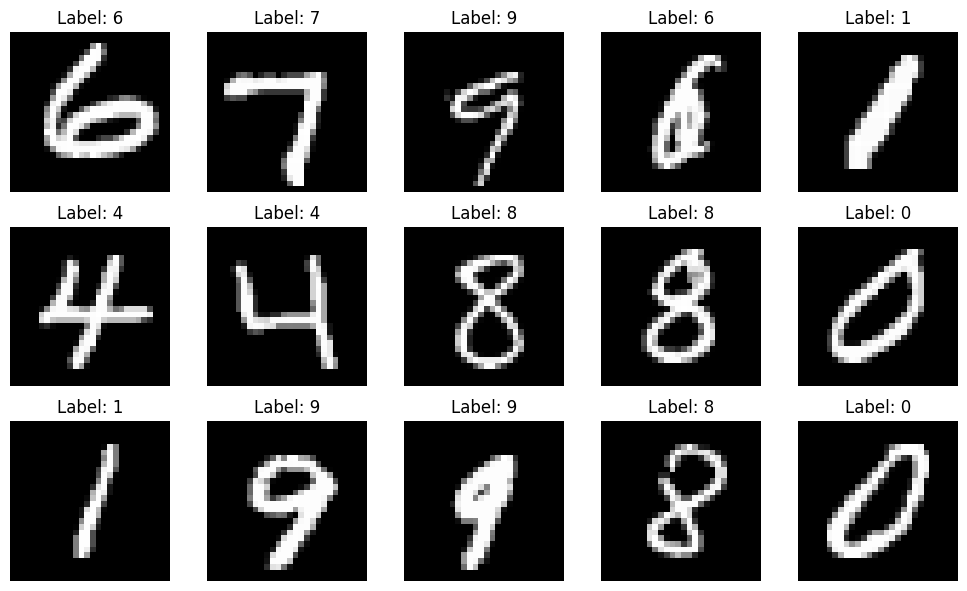

In [3]:
indices = np.random.randint(0, 60000, 15)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, idx in enumerate(indices):
    row, col = i // 5, i % 5
    axes[row, col].imshow(x_train[idx], cmap='gray')
    axes[row, col].set_title(f'Label: {y_train[idx]}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

In [4]:
def plot_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def build_model(hidden_layers):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        *[Dense(units, activation='relu') for units in hidden_layers],
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [6]:
def train_and_plot(hidden_layers, title, epochs=10):
    model = build_model(hidden_layers)
    history = model.fit(x_train, y_train, epochs=epochs, validation_split=0.1, verbose=1)
    plot_curves(history, title)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{title} Test Accuracy: {test_acc:.4f}')
    return history, test_acc, model  # Now returns 3 values: history, test_acc, model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9224 - loss: 0.2739 - val_accuracy: 0.9652 - val_loss: 0.1233
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9645 - loss: 0.1206 - val_accuracy: 0.9725 - val_loss: 0.0986
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9753 - loss: 0.0836 - val_accuracy: 0.9755 - val_loss: 0.0801
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9819 - loss: 0.0610 - val_accuracy: 0.9778 - val_loss: 0.0789
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9851 - loss: 0.0474 - val_accuracy: 0.9808 - val_loss: 0.0708
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9887 - loss: 0.0362 - val_accuracy: 0.9762 - val_loss: 0.0794
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9914 - loss: 0.0282 - val_accuracy: 0.9803 - val_loss: 0.0784
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9929 - loss: 0.0229 -

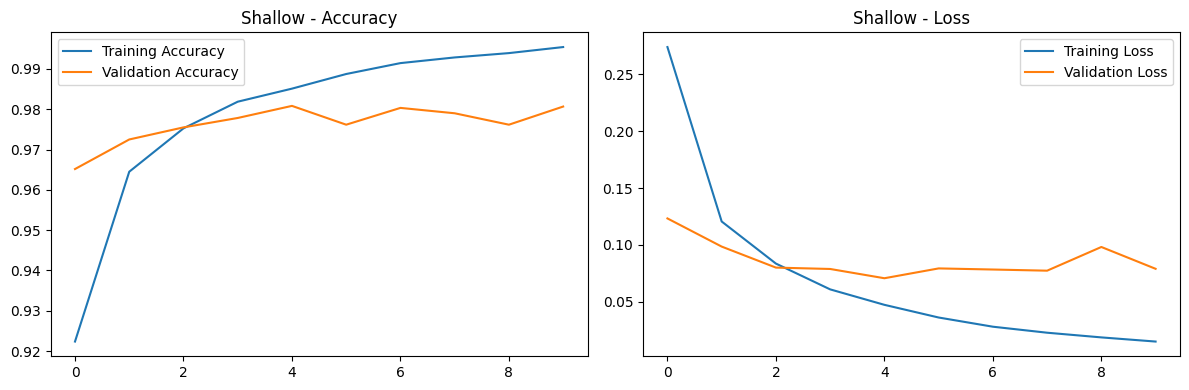

Shallow Test Accuracy: 0.9805
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9364 - loss: 0.2153 - val_accuracy: 0.9685 - val_loss: 0.1059
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9725 - loss: 0.0903 - val_accuracy: 0.9767 - val_loss: 0.0769
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9799 - loss: 0.0616 - val_accuracy: 0.9792 - val_loss: 0.0759
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9853 - loss: 0.0449 - val_accuracy: 0.9790 - val_loss: 0.0755
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9885 - loss: 0.0367 - val_accuracy: 0.9792 - val_loss: 0.0834
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9904 - loss: 0.0289 - val_accuracy: 0.9803 - val_loss: 0.0801
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9770 - val_loss: 0.0930
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step 

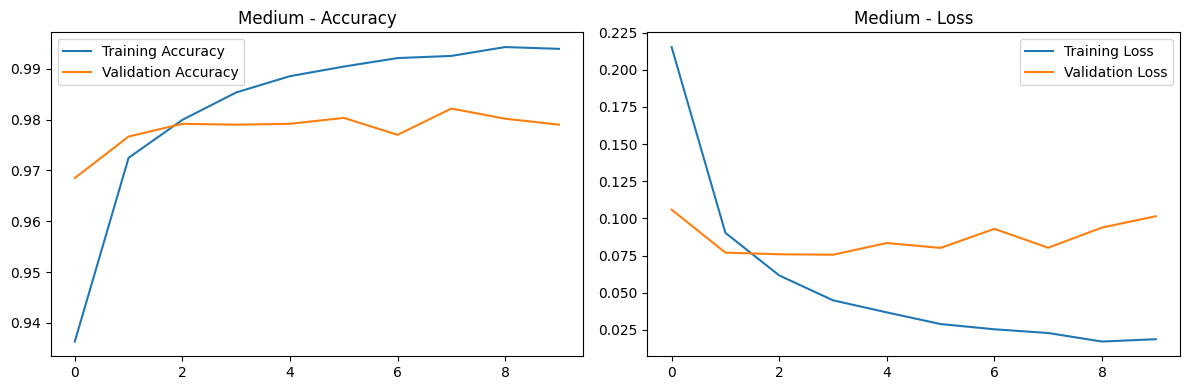

Medium Test Accuracy: 0.9776
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9381 - loss: 0.2032 - val_accuracy: 0.9702 - val_loss: 0.0939
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9710 - loss: 0.0941 - val_accuracy: 0.9742 - val_loss: 0.0863
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9799 - loss: 0.0630 - val_accuracy: 0.9783 - val_loss: 0.0787
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9782 - val_loss: 0.0879
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9875 - loss: 0.0406 - val_accuracy: 0.9800 - val_loss: 0.0699
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9782 - val_loss: 0.1017
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.9758 - val_loss: 0.0899
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 1

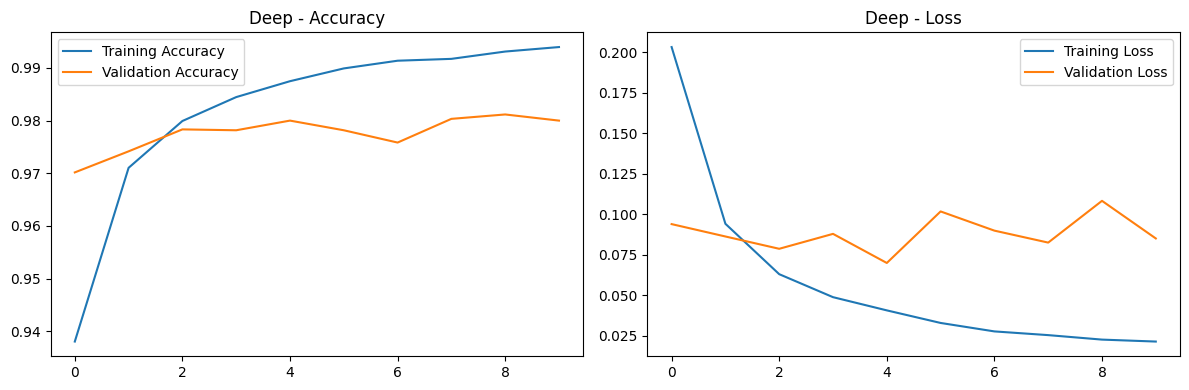

Deep Test Accuracy: 0.9778
Test Accuracies: Shallow=0.9805, Medium=0.9776, Deep=0.9778


In [7]:
hist1, acc1, model1 = train_and_plot([128], 'Shallow')
hist2, acc2, model2 = train_and_plot([256, 128], 'Medium')
hist3, acc3, model3 = train_and_plot([512, 256, 128], 'Deep')

print(f'Test Accuracies: Shallow={acc1:.4f}, Medium={acc2:.4f}, Deep={acc3:.4f}')

In [8]:
model1.save('shallow_mnist_model.h5')
model2.save('medium_mnist_model.h5')
model3.save('deep_mnist_model.h5')

print("Models saved: shallow_mnist_model.h5, medium_mnist_model.h5, deep_mnist_model.h5")

Models saved: shallow_mnist_model.h5, medium_mnist_model.h5, deep_mnist_model.h5


In [9]:
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = x_test.astype("float32") / 255.0

In [10]:
models = {
    "Shallow": model1,
    "Medium": model2,
    "Deep": model3
}

for name, model in models.items():

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    print(f"{name}: {acc*100:.2f}%")

Shallow: 98.05%
Medium: 97.76%
Deep: 97.78%


In [12]:
import random
import time

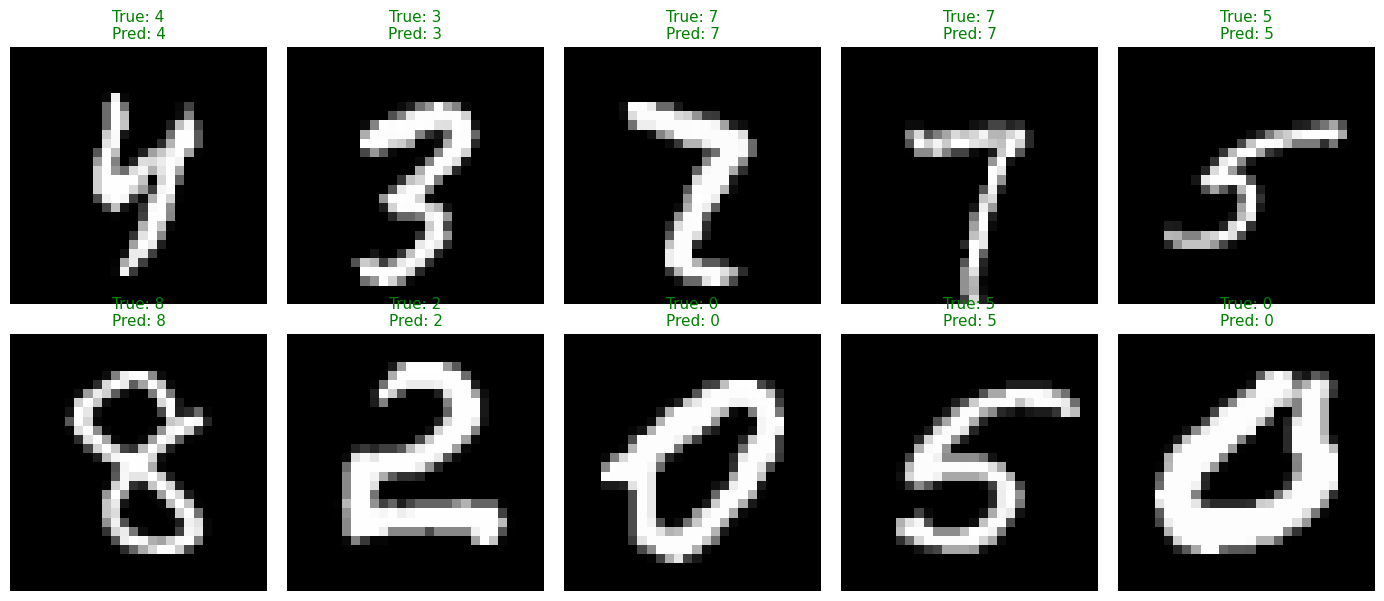

In [13]:
num_samples = 10

indices = random.sample(range(len(x_test)), num_samples)

fig, axes = plt.subplots(2,5, figsize=(14,6))

axes = axes.flatten()

for ax, idx in zip(axes, indices):

    image = x_test[idx]
    label = y_test[idx]

    pred = np.argmax(
        model3.predict(
            image.reshape(1,28,28),
            verbose=0
        )
    )

    color = "green" if pred==label else "red"

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"True: {label}\nPred: {pred}",
        color=color,
        fontsize=11
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Ground Truth : 2
Shallow  Prediction = 2 | Confidence = 1.0000 | Time = 120.02 ms
Medium   Prediction = 2 | Confidence = 1.0000 | Time = 115.79 ms
Deep     Prediction = 2 | Confidence = 1.0000 | Time = 75.30 ms


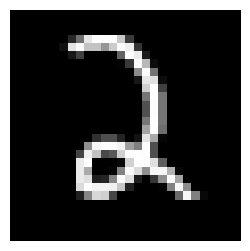

Ground Truth : 9
Shallow  Prediction = 9 | Confidence = 0.9999 | Time = 80.11 ms
Medium   Prediction = 9 | Confidence = 0.9045 | Time = 81.22 ms
Deep     Prediction = 9 | Confidence = 1.0000 | Time = 79.28 ms


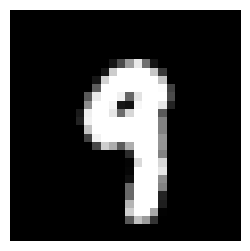

Ground Truth : 3
Shallow  Prediction = 3 | Confidence = 0.9985 | Time = 78.10 ms
Medium   Prediction = 3 | Confidence = 0.9855 | Time = 76.66 ms
Deep     Prediction = 3 | Confidence = 1.0000 | Time = 78.84 ms


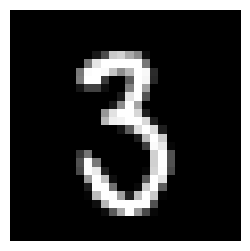

Ground Truth : 5
Shallow  Prediction = 5 | Confidence = 1.0000 | Time = 85.11 ms
Medium   Prediction = 5 | Confidence = 1.0000 | Time = 78.83 ms
Deep     Prediction = 5 | Confidence = 1.0000 | Time = 92.83 ms


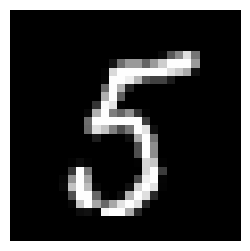

Ground Truth : 3
Shallow  Prediction = 3 | Confidence = 0.9996 | Time = 129.45 ms
Medium   Prediction = 3 | Confidence = 0.9995 | Time = 117.53 ms
Deep     Prediction = 3 | Confidence = 1.0000 | Time = 142.79 ms


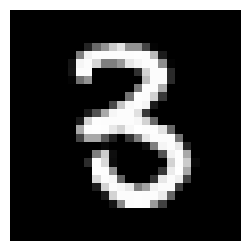

In [14]:
num_samples = 5

indices = random.sample(range(len(x_test)), num_samples)

for idx in indices:

    image = x_test[idx]
    label = y_test[idx]

    print("="*60)
    print(f"Ground Truth : {label}")

    for name, model in models.items():

        start = time.time()

        probs = model.predict(
            image.reshape(1,28,28),
            verbose=0
        )

        elapsed = (time.time()-start)*1000

        pred = np.argmax(probs)
        conf = np.max(probs)

        print(f"{name:8s} Prediction = {pred} | Confidence = {conf:.4f} | Time = {elapsed:.2f} ms")

    plt.figure(figsize=(3,3))
    plt.imshow(image,cmap="gray")
    plt.axis("off")
    plt.show()

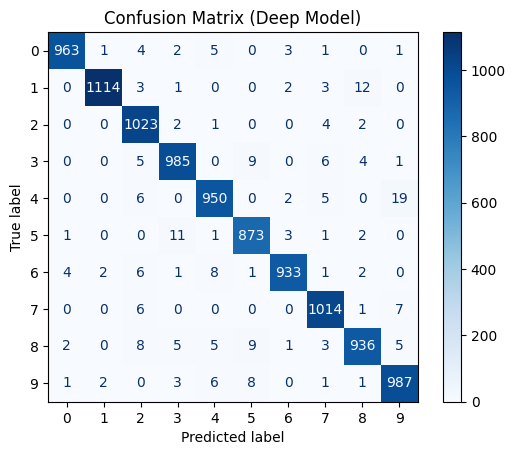

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = np.argmax(
    model3.predict(x_test, verbose=0),
    axis=1
)

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix (Deep Model)")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9918    0.9827    0.9872       980
           1     0.9955    0.9815    0.9885      1135
           2     0.9642    0.9913    0.9775      1032
           3     0.9752    0.9752    0.9752      1010
           4     0.9734    0.9674    0.9704       982
           5     0.9700    0.9787    0.9743       892
           6     0.9883    0.9739    0.9811       958
           7     0.9759    0.9864    0.9811      1028
           8     0.9750    0.9610    0.9679       974
           9     0.9676    0.9782    0.9729      1009

    accuracy                         0.9778     10000
   macro avg     0.9777    0.9776    0.9776     10000
weighted avg     0.9779    0.9778    0.9778     10000

